In [1]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path
from plotting_utils import get_short_model_name, get_nice_prompt_name

In [2]:
# This is where we'll want to add something like "Structured rules"
PROMPT_MAPPING = {
    "Accuracy-ChildBenefit-structuredOutput-v2.md": "Rules in URLs",
    "Accuracy-ChildBenefit-structuredOutput-v2.1_no_links.md": "Training data only",
    "Accuracy-ChildBenefit-structuredOutput-v2.2_no_links_rules_in_prompt.md": "Rules in prompt",
}

# Pricing per token
PRICING_MATRIX_USD = {
    "haiku-4-5": {"input": 1.00 / 1e6, "output": 5.00 / 1e6},
    "sonnet-4-5": {"input": 3.00 / 1e6, "output": 15.00 / 1e6},
    "opus-4-5": {"input": 5.00 / 1e6, "output": 25.00 / 1e6},
}

GBP_TO_USD_RATE = 1.33  # £1 = $1.33
SCALE_FACTOR = 1000  # Calculate cost per 1,000 cases

def calculate_usd_cost(
    model_short_name: str, prompt_tokens: int, completion_tokens: int
):
    name_lower = model_short_name.lower()
    rates = None

    if "haiku" in name_lower:
        rates = PRICING_MATRIX_USD["haiku-4-5"]
    elif "sonnet" in name_lower:
        rates = PRICING_MATRIX_USD["sonnet-4-5"]
    elif "opus" in name_lower:
        rates = PRICING_MATRIX_USD["opus-4-5"]

    if rates:
        return (prompt_tokens * rates["input"]) + (completion_tokens * rates["output"])
    return pd.NA

# Token usage

In [3]:
def build_cost_dataframe(
    base_dir_str: str,
    prompt_mapping: dict,
    gbp_to_usd_rate: float,
    scale_factor: float,
) -> pd.DataFrame:
    """
    Scan conversation JSON files and build a dataframe of per-case token usage
    and scaled GBP cost by configuration.
    """
    cost_data = []
    base_dir = Path(base_dir_str)
    for run_dir in base_dir.iterdir():
        if not run_dir.is_dir() or run_dir.name == "eval_reports":
            continue

        for file_path in run_dir.glob("*.conversation.json"):
            try:
                with open(file_path, "r") as f:
                    data = json.load(f)
            except json.JSONDecodeError:
                continue

            meta_block = data.get("meta", {})
            meta_content = meta_block.get("conversation", meta_block)
            run_config = meta_content.get("run_config", {})

            model_string = run_config.get("eligibility_model_string", "unknown")
            if "unknown" in model_string.lower():
                continue

            short_model_name = get_short_model_name(model_string)
            url_label = (
                "URLs ON"
                if run_config.get("url_tool_call_allowed", True)
                else "URLs OFF"
            )

            prompt_name, _ = get_nice_prompt_name(
                run_config.get("eligibility_prompt", ""),
                prompt_mapping,
            )

            config_label = f"{short_model_name} | {prompt_name} | {url_label}"

            plot_label = f"{short_model_name} | {prompt_mapping[prompt_name]} | {url_label}"

            usage = data.get("usage", {})
            prompt_tokens = usage.get("total_prompt_tokens")
            completion_tokens = usage.get("total_completion_tokens")

            if prompt_tokens is None or completion_tokens is None:
                continue

            cost_usd = calculate_usd_cost(
                short_model_name,
                prompt_tokens,
                completion_tokens,
            )

            if pd.isna(cost_usd):
                continue

            cost_gbp_scaled = (cost_usd / gbp_to_usd_rate) * scale_factor

            cost_data.append(
                {
                    "run_name": run_dir.name,
                    "case_id": data.get("case_id", file_path.stem),
                    "config_label": config_label,
                    "plot_label": plot_label,
                    "prompt_tokens": prompt_tokens,
                    "completion_tokens": completion_tokens,
                    "cost_gbp_scaled": cost_gbp_scaled,
                }
            )

    return pd.DataFrame(cost_data)

In [4]:
def plot_token_usage_summary(df_costs: pd.DataFrame) -> None:
    """
    Plot token usage by configuration.

    Produces:
    - a distribution plot of total tokens per request
    - a stacked bar chart of mean prompt vs completion tokens
    - a summary table of average token usage
    """

    df_plot = df_costs.assign(
        total_tokens=df_costs["prompt_tokens"] + df_costs["completion_tokens"]
    )

    label_order = (
        df_plot.groupby("plot_label")["total_tokens"]
        .median()
        .sort_values()
        .index
        .tolist()
    )

    palette = dict(
        zip(label_order, sns.color_palette("Set3", n_colors=len(label_order)))
    )

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1: total token distribution
    sns.boxplot(
        data=df_plot,
        x="total_tokens",
        y="plot_label",
        hue="plot_label",
        order=label_order,
        hue_order=label_order,
        palette=palette,
        showfliers=False,
        width=0.5,
        dodge=False,
        legend=False,
        ax=axes[0],
    )

    sns.stripplot(
        data=df_plot,
        x="total_tokens",
        y="plot_label",
        order=label_order,
        color="black",
        alpha=0.5,
        jitter=True,
        size=4,
        ax=axes[0],
    )

    axes[0].set_title("Total Tokens per Request", fontsize=14, pad=10)
    axes[0].set_xlabel("Total Tokens (Prompt + Completion)", fontsize=12)
    axes[0].set_ylabel("Model Configuration", fontsize=12)
    axes[0].grid(axis="x", linestyle="--", alpha=0.7)

    # Plot 2: mean token split
    token_summary = (
        df_plot.groupby("plot_label")[["prompt_tokens", "completion_tokens"]]
        .mean()
        .reindex(label_order)
        .reset_index()
    )

    token_summary.set_index("plot_label").plot(
        kind="barh",
        stacked=True,
        ax=axes[1],
    )

    axes[1].set_title("Average Token Split", fontsize=14, pad=10)
    axes[1].set_xlabel("Average Token Count", fontsize=12)
    axes[1].set_ylabel("")
    axes[1].legend(
        ["Prompt Tokens", "Completion Tokens"],
        loc="lower right",
    )
    axes[1].grid(axis="x", linestyle="--", alpha=0.7)

    plt.tight_layout()
    plt.show()

    token_summary["total_tokens"] = token_summary["prompt_tokens"] + token_summary["completion_tokens"]
    token_summary.sort_values("total_tokens", inplace=True)
    print("\n=== Average Token Usage Summary ===")
    display(
        token_summary.style.format(
            {
                "prompt_tokens": "{:,.0f}",
                "completion_tokens": "{:,.0f}",
                "total_tokens": "{:,.0f}",
            }
        )
    )

In [5]:
df_costs = build_cost_dataframe(
    "./testOutputs/child_benefit",
    PROMPT_MAPPING,
    GBP_TO_USD_RATE,
    SCALE_FACTOR,
)
df_costs

,run_name,case_id,config_label,plot_label,prompt_tokens,completion_tokens,cost_gbp_scaled
0,2026-03-05T18:24:18.571514__Model=claude-opus-...,MULTI_MIXED_THREE_MIXED,claude-opus-4-5 | Accuracy-ChildBenefit-struct...,claude-opus-4-5 | Rules in URLs | URLs ON,60230,1809,260.432331
1,2026-03-05T18:24:18.571514__Model=claude-opus-...,RESIDENCY_FAIL_MULTI,claude-opus-4-5 | Accuracy-ChildBenefit-struct...,claude-opus-4-5 | Rules in URLs | URLs ON,37553,1619,171.609023
2,2026-03-05T18:24:18.571514__Model=claude-opus-...,RND_047,claude-opus-4-5 | Accuracy-ChildBenefit-struct...,claude-opus-4-5 | Rules in URLs | URLs ON,36257,1274,160.251880
3,2026-03-05T18:24:18.571514__Model=claude-opus-...,RESPONSIBILITY_PASS_UPKEEP_SUFFICIENT,claude-opus-4-5 | Accuracy-ChildBenefit-struct...,claude-opus-4-5 | Rules in URLs | URLs ON,61598,1738,264.240602
4,2026-03-05T18:24:18.571514__Model=claude-opus-...,RND_023,claude-opus-4-5 | Accuracy-ChildBenefit-struct...,claude-opus-4-5 | Rules in URLs | URLs ON,51201,1698,224.402256
...,...,...,...,...,...,...,...
589,2026-03-06T17:08:17.760944__Model=claude-sonne...,RND_018,claude-sonnet-4-5 | Accuracy-ChildBenefit-stru...,claude-sonnet-4-5 | Rules in prompt | URLs OFF,35825,686,88.545113
590,2026-03-06T17:08:17.760944__Model=claude-sonne...,HOSPITAL_PASS_UNDER_12_WEEKS,claude-sonnet-4-5 | Accuracy-ChildBenefit-stru...,claude-sonnet-4-5 | Rules in prompt | URLs OFF,47215,979,117.541353
591,2026-03-06T17:08:17.760944__Model=claude-sonne...,RND_034,claude-sonnet-4-5 | Accuracy-ChildBenefit-stru...,claude-sonnet-4-5 | Rules in prompt | URLs OFF,54935,1183,137.255639
592,2026-03-06T17:08:17.760944__Model=claude-sonne...,RND_004,claude-sonnet-4-5 | Accuracy-ChildBenefit-stru...,claude-sonnet-4-5 | Rules in prompt | URLs OFF,40741,910,102.160150


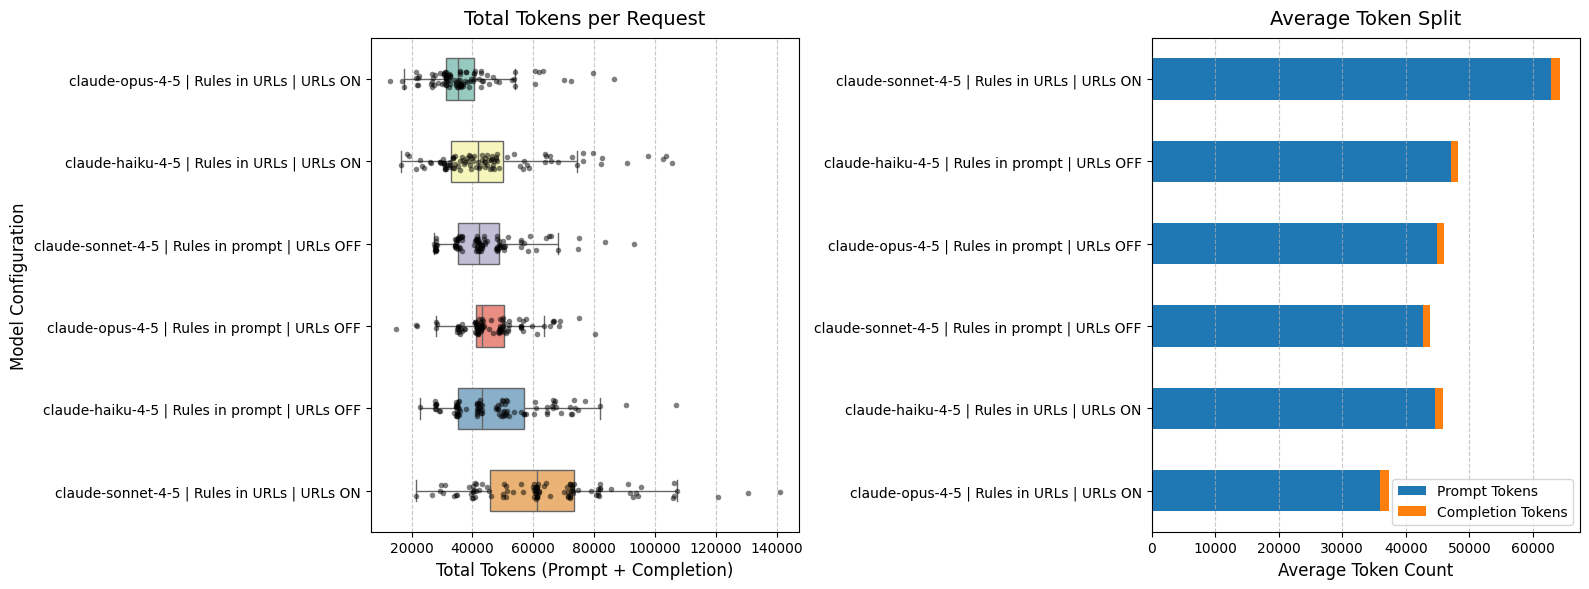


=== Average Token Usage Summary ===


,plot_label,prompt_tokens,completion_tokens,total_tokens
0,claude-opus-4-5 | Rules in URLs | URLs ON,"36,021","1,291","37,312"
2,claude-sonnet-4-5 | Rules in prompt | URLs OFF,"42,784","1,058","43,842"
1,claude-haiku-4-5 | Rules in URLs | URLs ON,"44,629","1,268","45,897"
3,claude-opus-4-5 | Rules in prompt | URLs OFF,"44,913","1,167","46,080"
4,claude-haiku-4-5 | Rules in prompt | URLs OFF,"47,132","1,095","48,228"
5,claude-sonnet-4-5 | Rules in URLs | URLs ON,"62,840","1,360","64,200"


In [6]:
plot_token_usage_summary(df_costs)

# Costs: warning this is extremely speculative and should not be treated as any kind of real cost
It is simply a way to visualise the effect of different token costs per model when multiplied by token usage

In [7]:
def plot_token_cost_estimates(
    df_costs: pd.DataFrame,
    scale_factor: int,
) -> None:
    """
    Visualise token-derived cost estimates per configuration.

    Costs are extrapolated from API token usage and scaled to the specified
    number of executions. These figures represent approximate token costs
    only and do not reflect total operational costs.
    """

    label_order = (
        df_costs.groupby("plot_label")["cost_gbp_scaled"]
        .median()
        .sort_values()
        .index
        .tolist()
    )

    palette = dict(
        zip(label_order, sns.color_palette("Set3", n_colors=len(label_order)))
    )

    fig, ax = plt.subplots(figsize=(12, 6))

    sns.boxplot(
        data=df_costs,
        x="cost_gbp_scaled",
        y="plot_label",
        hue="plot_label",
        order=label_order,
        hue_order=label_order,
        palette=palette,
        showfliers=False,
        width=0.5,
        dodge=False,
        legend=False,
        ax=ax,
    )

    sns.stripplot(
        data=df_costs,
        x="cost_gbp_scaled",
        y="plot_label",
        color="black",
        alpha=0.5,
        jitter=True,
        size=4,
        ax=ax,
    )

    ax.set_title(
        f"Token-Based Cost Estimates per {scale_factor:,} Executions",
        fontsize=14,
        pad=15,
    )

    ax.set_xlabel(
        f"Extrapolated Token Cost (GBP) per {scale_factor:,} Cases",
        fontsize=12,
    )

    ax.set_ylabel("Model Configuration", fontsize=12)

    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter("£%.2f"))

    ax.grid(axis="x", linestyle="--", alpha=0.7)

    plt.tight_layout()
    plt.show()

    # Summary table
    print(f"\n=== Token-Based Cost Extrapolation per {scale_factor:,} Requests ===")

    summary = (
        df_costs.groupby("plot_label")["cost_gbp_scaled"]
        .agg(["count", "mean", "median", "max"])
    )
    summary.sort_values("mean", inplace=True)
    summary["mean"] = summary["mean"].map(lambda x: f"£{x:.2f}")
    summary["median"] = summary["median"].map(lambda x: f"£{x:.2f}")
    summary["max"] = summary["max"].map(lambda x: f"£{x:.2f}")
    
    display(summary)

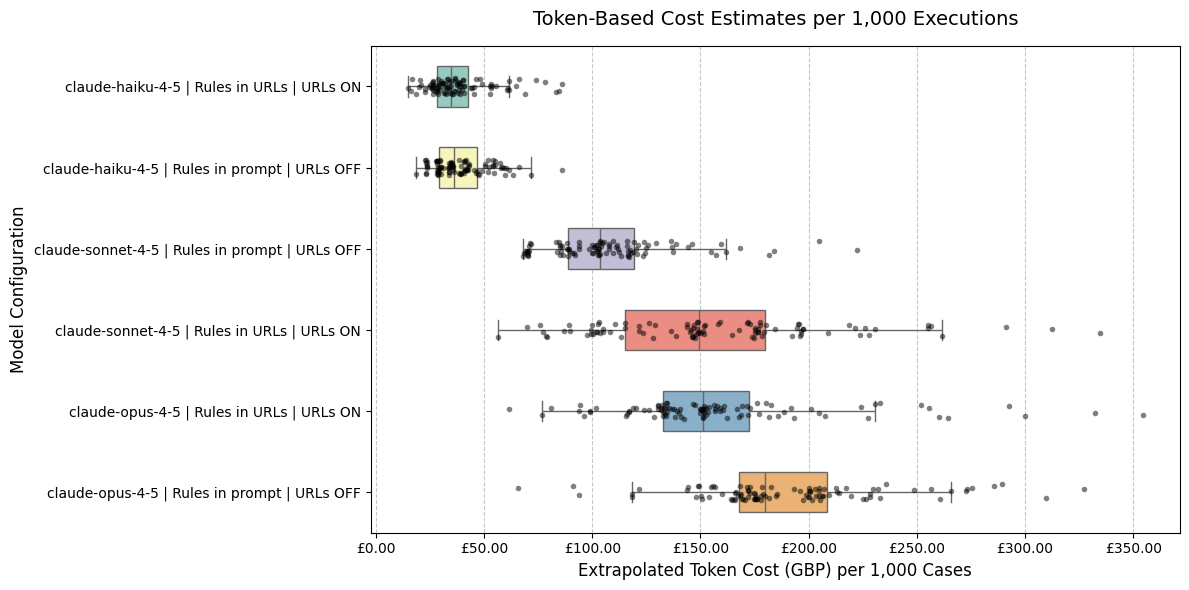


=== Token-Based Cost Extrapolation per 1,000 Requests ===


,count,mean,median,max
plot_label,,,,
claude-haiku-4-5 | Rules in URLs | URLs ON,99,£38.32,£34.91,£86.23
claude-haiku-4-5 | Rules in prompt | URLs OFF,99,£39.56,£36.01,£86.00
claude-sonnet-4-5 | Rules in prompt | URLs OFF,99,£108.43,£103.64,£222.23
claude-sonnet-4-5 | Rules in URLs | URLs ON,99,£157.08,£149.14,£334.80
claude-opus-4-5 | Rules in URLs | URLs ON,99,£159.69,£151.08,£354.62
claude-opus-4-5 | Rules in prompt | URLs OFF,99,£190.78,£179.62,£327.25


In [8]:
plot_token_cost_estimates(df_costs, SCALE_FACTOR)

# Tool usage

In [9]:
def build_url_fetch_dataframe(
    base_dir_str: str,
    prompt_mapping: dict,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Scan conversation JSON files and build URL-fetch records plus per-configuration
    case counts.

    Returns:
        df_urls:
            One row per fetched URL, with configuration label and cleaned URL.
        df_case_counts:
            One row per configuration with the number of cases observed.
    """
    url_fetches = []
    base_dir = Path(base_dir_str)
    case_counts: dict[str, int] = {}

    for run_dir in base_dir.iterdir():
        if not run_dir.is_dir() or run_dir.name == "eval_reports":
            continue

        for file_path in run_dir.glob("*.conversation.json"):
            try:
                with open(file_path, "r") as f:
                    data = json.load(f)
            except json.JSONDecodeError:
                continue

            meta_block = data.get("meta", {})
            meta_content = meta_block.get("conversation", meta_block)
            run_config = meta_content.get("run_config", {})

            model_string = run_config.get("eligibility_model_string", "unknown")
            if "unknown" in model_string.lower():
                continue

            short_model_name = get_short_model_name(model_string)
            url_label = (
                "URLs ON"
                if run_config.get("url_tool_call_allowed", True)
                else "URLs OFF"
            )
            prompt_name, _ = get_nice_prompt_name(
                run_config.get("eligibility_prompt", ""),
                prompt_mapping,
            )

            config_label = f"{short_model_name} | {prompt_name} | {url_label}"

            case_counts[config_label] = case_counts.get(config_label, 0) + 1

            for tool in data.get("tool_activity", []):
                args = tool.get("arguments", {})
                url = args.get("url", "")
                if not url:
                    continue

                clean_url = url.replace("https://www.gov.uk/child-benefit", "")
                if clean_url == "":
                    clean_url = "/eligibility"

                url_fetches.append(
                    {
                        "config_label": config_label,
                        "url": clean_url,
                    }
                )

    df_urls = pd.DataFrame(url_fetches)
    df_case_counts = pd.DataFrame(
        [
            {"config_label": config_label, "case_count": count}
            for config_label, count in case_counts.items()
        ]
    )

    return df_urls, df_case_counts


def plot_url_fetch_summary(
    df_urls: pd.DataFrame,
    df_case_counts: pd.DataFrame,
) -> None:
    """
    Plot average URL fetches per case by configuration and show a detailed table.
    """

    df_plot = df_urls.copy()

    df_plot.loc[
        df_plot["url"].str.contains("(Main Page)", regex=False, na=False),
        "url",
    ] = "[...]/eligibility"

    url_summary = (
        df_plot.groupby(["config_label", "url"])
        .size()
        .reset_index(name="total_fetches")
        .merge(df_case_counts, on="config_label", how="left")
    )

    url_summary["avg_fetches_per_case"] = (
        url_summary["total_fetches"] / url_summary["case_count"]
    )

    config_order = (
        url_summary.groupby("config_label")["avg_fetches_per_case"]
        .sum()
        .sort_values(ascending=False)
        .index
        .tolist()
    )

    palette = dict(
        zip(config_order, sns.color_palette("Set2", n_colors=len(config_order)))
    )

    fig, ax = plt.subplots(figsize=(14, 7))

    sns.barplot(
        data=url_summary,
        x="url",
        y="avg_fetches_per_case",
        hue="config_label",
        hue_order=config_order,
        palette=palette,
        ax=ax,
    )

    ax.set_title(
        "URL Fetch Patterns by Configuration\n(Average fetches per URL per case)",
        fontsize=15,
        pad=15,
    )
    ax.set_xlabel("")
    ax.set_ylabel("Average fetches per case", fontsize=12)

    ax.tick_params(axis="x", rotation=25, labelsize=10)
    for label in ax.get_xticklabels():
        label.set_ha("right")

    ax.legend(
        title="Model Configuration",
        bbox_to_anchor=(0.5, -0.2),
        loc="upper center",
        ncol=2,
    )
    ax.grid(axis="y", linestyle="--", alpha=0.7)

    plt.tight_layout()
    plt.show()

    print("\n=== Detailed URL Fetch Rates ===")
    display(
        url_summary.pivot(
            index="url",
            columns="config_label",
            values="avg_fetches_per_case",
        )
        .fillna(0)
        .round(2)
    )

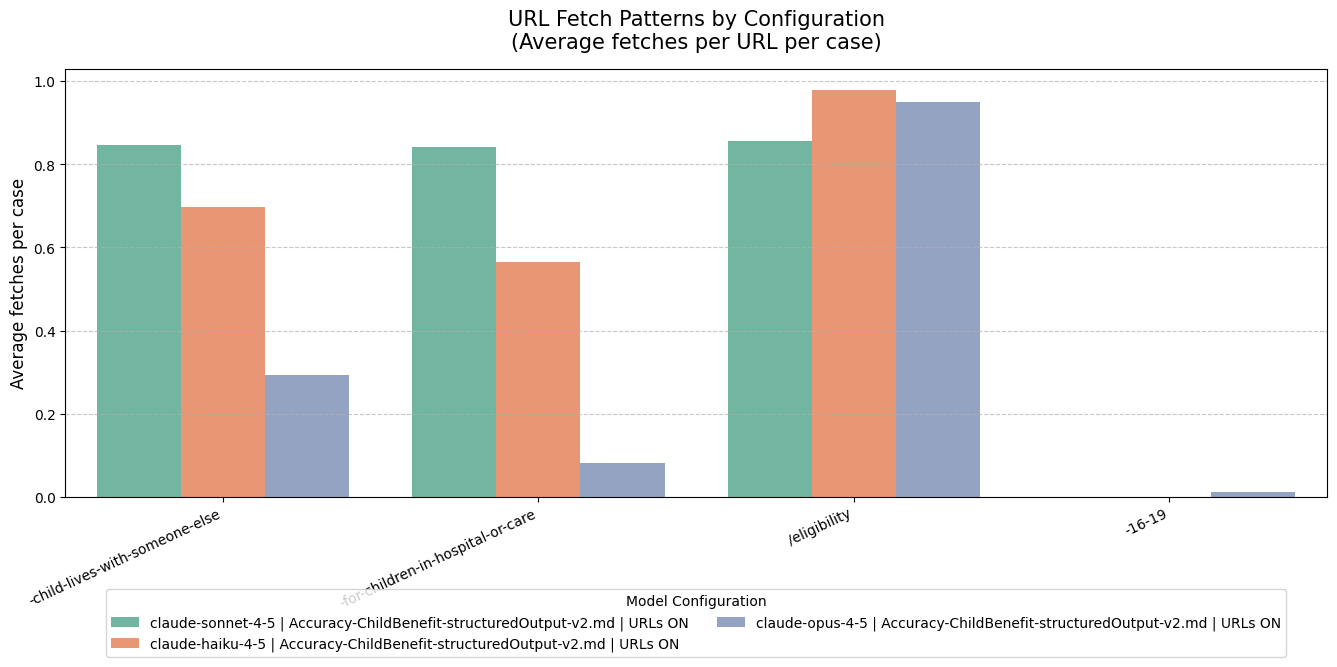


=== Detailed URL Fetch Rates ===


config_label,claude-haiku-4-5 | Accuracy-ChildBenefit-structuredOutput-v2.md | URLs ON,claude-opus-4-5 | Accuracy-ChildBenefit-structuredOutput-v2.md | URLs ON,claude-sonnet-4-5 | Accuracy-ChildBenefit-structuredOutput-v2.md | URLs ON
url,,,
-16-19,0.00,0.01,0.00
-child-lives-with-someone-else,0.70,0.29,0.85
-for-children-in-hospital-or-care,0.57,0.08,0.84
/eligibility,0.98,0.95,0.86


In [10]:
df_urls, df_case_counts = build_url_fetch_dataframe(
    base_dir_str =    "./testOutputs/child_benefit",
    prompt_mapping=PROMPT_MAPPING,
)

plot_url_fetch_summary(df_urls, df_case_counts)